Here, we preprocess the [immune dictionary](https://doi.org/10.1038/s41586-023-06816-9) dataset as described in scPerturb in anticipation that datasets from scPerturb will also be used. rds files are downloaded from the Immune Dictionary [download](https://www.immune-dictionary.org/app/home) page.

In [1]:
import os

import scanpy as sc
import anndata as ad
from kneed import KneeLocator

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import omnipath as op

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore', module='pandas')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='ipykernel')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings(action='ignore', category=UserWarning, module='scanpy')

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS.preprocess import get_tf_activity, embed_tf_activity, transform_tf_activity, tf_to_adata
from scLEMBAS import io, preprocess

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [3]:
quick_run = False # whether to subsample data and use quicker/less mem intensive (less accurate) versions of parameters

quick_dict = {'quick': {'perm': int(10), 'n_samples': int(1e3), 'batch_size': int(2e3)},
             'full': {'perm': int(1e3), 'n_samples': None, 'batch_size': int(1e4)}}
if quick_run: 
    run_key = 'quick'
else:
    run_key = 'full'


In [4]:
directory_names = [
    #data_path,
    #os.path.join(data_path, 'raw'), os.path.join(data_path, 'raw', 'immune_dictionary'),
    os.path.join(data_path, 'interim'), os.path.join(data_path, 'interim', 'immune_dictionary_h5ad'),
    os.path.join(data_path, 'processed'), os.path.join(data_path, 'figures')
]

for directory_name in directory_names:
    if not os.path.exists(directory_name):
        os.makedirs(directory_name)


# Load Files

In [5]:
# h5ad_in_path = os.path.join(data_path, 'interim', 'immune_dictionary_h5ad')
# file_names = os.listdir(h5ad_in_path)

# imm_d = {}
# for file_name in file_names:
#     cell_type = file_name.split('ref_data_')[1].split('.h5ad')[0]
#     adata = sc.read_h5ad(os.path.join(h5ad_in_path, file_name)) # Seurat counts slot in adata.raw.X, data slot in adata.X
#     imm_d[cell_type] = adata
# adata = ad.concat(list(imm_d.values()),  join="outer")

# sco = sorted(adata.obs.seurat_clusters.unique())
# adata.obs.seurat_clusters = pd.Categorical(adata.obs.seurat_clusters,
#                                            categories=sco,
#                                            ordered=True)
# adata.write_h5ad(os.path.join(data_path, 'interim', 'id_all.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'interim', 'id_all.h5ad'))

In [6]:
if quick_run:
    adata = sc.pp.subsample(adata, n_obs = quick_dict[run_key]['n_samples'], copy = True, random_state = seed) 

Start preprocessing from the raw data:

In [7]:
adata = adata.raw.to_adata()
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
# sc.pp.scrublet(raw_adata, batch_key="sample")

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=3000, batch_key="sample")

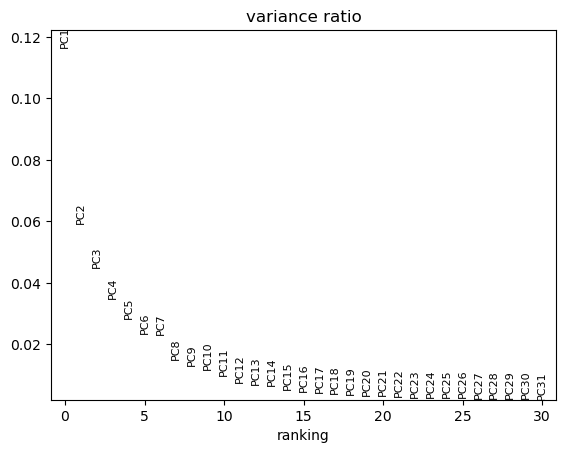

The elbow was automatically identified at PC 8


In [8]:
# sc.tl.pca(adata)
# variance_ratio = adata.uns['pca']['variance_ratio']
# pcs = np.array(range(len(variance_ratio))) + 1
# kneedle = KneeLocator(x = pcs, y = variance_ratio, curve='convex', direction='decreasing')
# adata.uns['pca']['pca_rank'] = kneedle.elbow

# sc.pp.neighbors(adata, n_pcs = adata.uns['pca']['pca_rank'])
# sc.tl.umap(adata)
# adata.write_h5ad(os.path.join(data_path, 'interim', 'id_all_embedded.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'interim', 'id_all_embedded.h5ad'))

sc.pl.pca_variance_ratio(adata)
print('The elbow was automatically identified at PC {}'.format(adata.uns['pca']['pca_rank']))

<font color='red'>Will probably want to re-process the data from raw fastqs or atleast from raw UMI counts at some point</font>

# Get TF activity estimates:

In [ ]:
kwargs = {'args' : {'wsum' : {'times': quick_dict[run_key]['perm'], 'batch_size': quick_dict[run_key]['batch_size']},
                       'ulm' : {'batch_size': quick_dict[run_key]['batch_size']}, 
                        'mlm': {'batch_size': quick_dict[run_key]['batch_size']}
                       }, 
#          'methods': ['wsum', 'ulm', 'mlm'], 
         'cns_metds': ['ulm_estimate', 'mlm_estimate', 'wsum_estimate']}
# default is wsum_norm, which introduces inf values that result in nan when z-scoring..
# also intuitively doesnt make sense to z-score an already normalized value
# particularly when the other z-scores or on the non-normalized values

adata = get_tf_activity(adata, organism = 'mouse', grn = 'collectri', verbose = True,
                consensus = True, hvg = False,
                min_n = 5, use_raw = False, filter_pvals = False, pval_thresh = 0.05, **kwargs)
adata.write_h5ad(os.path.join(data_path, 'processed', 'expr_scored.h5ad'))


Running scores.
Running mlm on mat with 96034 samples and 20179 targets for 673 sources.


100%|█████████████████████████████████████████| 10/10 [02:31<00:00, 15.18s/it]


Running ulm on mat with 96034 samples and 20179 targets for 673 sources.


100%|█████████████████████████████████████████| 10/10 [00:26<00:00,  2.65s/it]


Running wsum on mat with 96034 samples and 20179 targets for 673 sources.


 10%|███▊                                  | 1/10 [34:18<5:08:42, 2058.11s/it]

In [ ]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'expr_scored.h5ad'))
fn_csv = os.path.join(data_path, 'interim', 'TF_activity.csv') 
for key in adata.obsm:
    if key.endswith('estimate') or key.endswith('pvals'):
        fn_csv_ = fn_csv.replace('TF_activity', key + '_TF_activity')
        adata.obsm[key].to_csv(fn_csv_)

        if key == 'consensus_estimate':
            transformed_consensus = transform_tf_activity(adata.obsm[key])

adata.obsm['consensus_estimate_transformed'] = transformed_consensus
tf_adata = tf_to_adata(adata, estimate_key = 'consensus_estimate_transformed')

io.write_tfad(tf_adata, file_name = os.path.join(data_path, 'interim', 'ID_tf_activity.h5ad'))